Loaded 24 models
forecast_time (IST)  predicted_visibility (m)  actual_visibility (m)  error (m)  abs_error (m)
   2026-04-24 12:00                      5277                   6000       -723            723
   2026-04-24 13:00                      7085                   6000       1085           1085
   2026-04-24 14:00                      5987                   7000      -1013           1013
   2026-04-24 15:00                      5484                   7000      -1516           1516
   2026-04-24 16:00                      5683                   7000      -1317           1317
   2026-04-24 17:00                      5728                   8000      -2272           2272
   2026-04-24 18:00                      5045                   6000       -955            955
   2026-04-24 19:00                      5944                   6000        -56             56
   2026-04-24 20:00                      5757                   6000       -243            243
   2026-04-24 21:00              

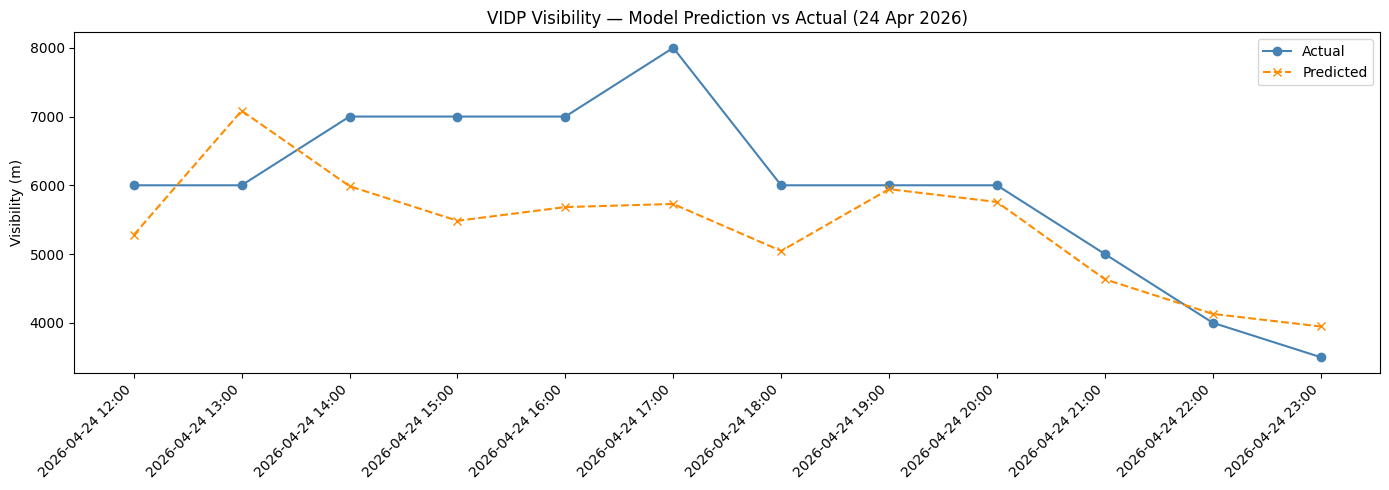

Plot saved to vidp_validation_24apr2026.png


In [1]:
import pandas as pd
import numpy as np
import re
import joblib
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

MODEL_DIR = Path("models_12h")
SCALE = 1.018
OFFSET = 1

def parse_metar(metar):
    out = {"vis": np.nan, "wind": 0, "temp": np.nan,
           "dew": np.nan, "fog": 0, "mist": 0}
    m = re.search(r"\b(\d{4})\b", metar)
    if m:
        out["vis"] = int(m.group(1))
    m = re.search(r"(\d{2,3})KT", metar)
    if m:
        out["wind"] = int(m.group(1))
    m = re.search(r"(M?\d{2})/(M?\d{2})", metar)
    if m:
        out["temp"] = int(m.group(1).replace("M", "-"))
        out["dew"]  = int(m.group(2).replace("M", "-"))
    out["fog"]  = int("FG" in metar)
    out["mist"] = int(("BR" in metar) or ("MIFG" in metar))
    return out

FEATURES = [
    "wind", "temp", "dew", "fog", "mist",
    "hour", "month", "night", "winter"
] + [f"vis_lag_{l}" for l in range(1, 13)]


models = {}
for step in range(1, 25):
    path = MODEL_DIR / f"vis_t+{step}.pkl"
    if path.exists():
        models[step] = joblib.load(path)
print(f"Loaded {len(models)} models")

input_metars = [
    "METAR VIDP 240000Z 20003KT 2500 HZ NSC 28/13 Q1005 NOSIG=",    
    "METAR VIDP 240030Z VRB02KT 2500 HZ NSC 28/13 Q1006 NOSIG=",
    "METAR VIDP 240100Z VRB02KT 2700 HZ NSC 28/13 Q1006 NOSIG=",
    "METAR VIDP 240130Z 24004KT 2700 HZ NSC 29/12 Q1006 NOSIG=",
    "METAR VIDP 240200Z 25004KT 3500 HZ NSC 30/12 Q1007 NOSIG=",
    "METAR VIDP 240230Z 24007KT 4000 HZ NSC 31/11 Q1007 NOSIG=",
    "METAR VIDP 240300Z 25008KT 4000 HZ NSC 32/10 Q1007 NOSIG=",
    "METAR VIDP 240330Z 24008KT 4500 HZ NSC 33/11 Q1008 NOSIG=",
    "METAR VIDP 240400Z 27010KT 5000 HZ NSC 34/11 Q1008 NOSIG=",
    "METAR VIDP 240430Z 27007KT 5000 HZ NSC 34/11 Q1008 NOSIG=",
    "METAR VIDP 240500Z 26007KT 6000 NSC 36/12 Q1008 NOSIG=",
    "METAR VIDP 240530Z 27007KT 6000 NSC 37/12 Q1007 NOSIG=",      
]

latest_valid = datetime(2026, 4, 24, 11, 0)  
actual_data = [
    ("2026-04-24 12:00", 6000),  
    ("2026-04-24 12:30", 6000),
    ("2026-04-24 13:00", 6000),
    ("2026-04-24 13:30", 7000),
    ("2026-04-24 14:00", 7000),
    ("2026-04-24 14:30", 7000),
    ("2026-04-24 15:00", 7000),
    ("2026-04-24 15:30", 7000),
    ("2026-04-24 16:00", 7000),
    ("2026-04-24 16:30", 8000),
    ("2026-04-24 17:00", 8000),
    ("2026-04-24 17:30", 7000),
    ("2026-04-24 18:00", 6000),
    ("2026-04-24 18:30", 6000),
    ("2026-04-24 19:00", 6000),
    ("2026-04-24 19:30", 6000),
    ("2026-04-24 20:00", 6000),
    ("2026-04-24 20:30", 5000),
    ("2026-04-24 21:00", 5000),
    ("2026-04-24 21:30", 4500),
    ("2026-04-24 22:00", 4000),
    ("2026-04-24 22:30", 4000),
    ("2026-04-24 23:00", 3500),
    ("2026-04-24 23:30", 2700),  
]

latest = parse_metar(input_metars[-1])
vis_values = [parse_metar(m)["vis"] for m in input_metars[-12:]]

lag_features = {}
for l in range(1, 13):
    idx = -(l + 1) if l % 3 == 0 else -l
    try:
        val = vis_values[idx]
    except IndexError:
        val = np.nan
    lag_features[f"vis_lag_{l}"] = val * SCALE if not np.isnan(val) else np.nan

hour  = latest_valid.hour
month = latest_valid.month

row = {
    "wind":   latest["wind"],
    "temp":   latest["temp"],
    "dew":    latest["dew"],
    "fog":    latest["fog"],
    "mist":   latest["mist"],
    "hour":   hour,
    "month":  month,
    "night":  int(hour >= 18 or hour <= 6),
    "winter": int(month in [11, 12, 1, 2]),
    **lag_features
}

X = pd.DataFrame([row])[FEATURES]

predicted = []
for step in range(1, 25):
    pred_vis = models[step].predict(X)[0]
    forecast_time = latest_valid + timedelta(hours=step)
    predicted.append({
        "forecast_time (IST)": forecast_time.strftime("%Y-%m-%d %H:%M"),
        "predicted_visibility (m)": round(pred_vis)
    })

pred_df = pd.DataFrame(predicted)


actual_df = pd.DataFrame(actual_data, columns=["forecast_time (IST)", "actual_visibility (m)"])

results = pred_df.merge(actual_df, on="forecast_time (IST)")
results["error (m)"] = results["predicted_visibility (m)"] - results["actual_visibility (m)"]
results["abs_error (m)"] = results["error (m)"].abs()

print(results.to_string(index=False))
print(f"\nMAE  : {results['abs_error (m)'].mean():.0f} m")
print(f"RMSE : {np.sqrt((results['error (m)']**2).mean()):.0f} m")
print(f"Max error : {results['abs_error (m)'].max():.0f} m")

results.to_excel("vidp_validation_24apr2026.xlsx", index=False)
print("\nValidation saved to vidp_validation_24apr2026.xlsx")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(results["forecast_time (IST)"], results["actual_visibility (m)"],
         label="Actual", marker="o", color="steelblue")
plt.plot(results["forecast_time (IST)"], results["predicted_visibility (m)"],
         label="Predicted", marker="x", linestyle="--", color="darkorange")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Visibility (m)")
plt.title("VIDP Visibility — Model Prediction vs Actual (24 Apr 2026)")
plt.legend()
plt.tight_layout()
plt.savefig("vidp_validation_24apr2026.png", dpi=150)
plt.show()
print("Plot saved to vidp_validation_24apr2026.png")